In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import Sequential, layers, optimizers, callbacks
import seaborn as sns
from tensorflow import keras

In [2]:
# Charger CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Pixel range: [{X_train.min()}, {X_train.max()}]")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Pixel range: [0, 255]


In [3]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print(X_train_norm.shape)
print(X_test_norm.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


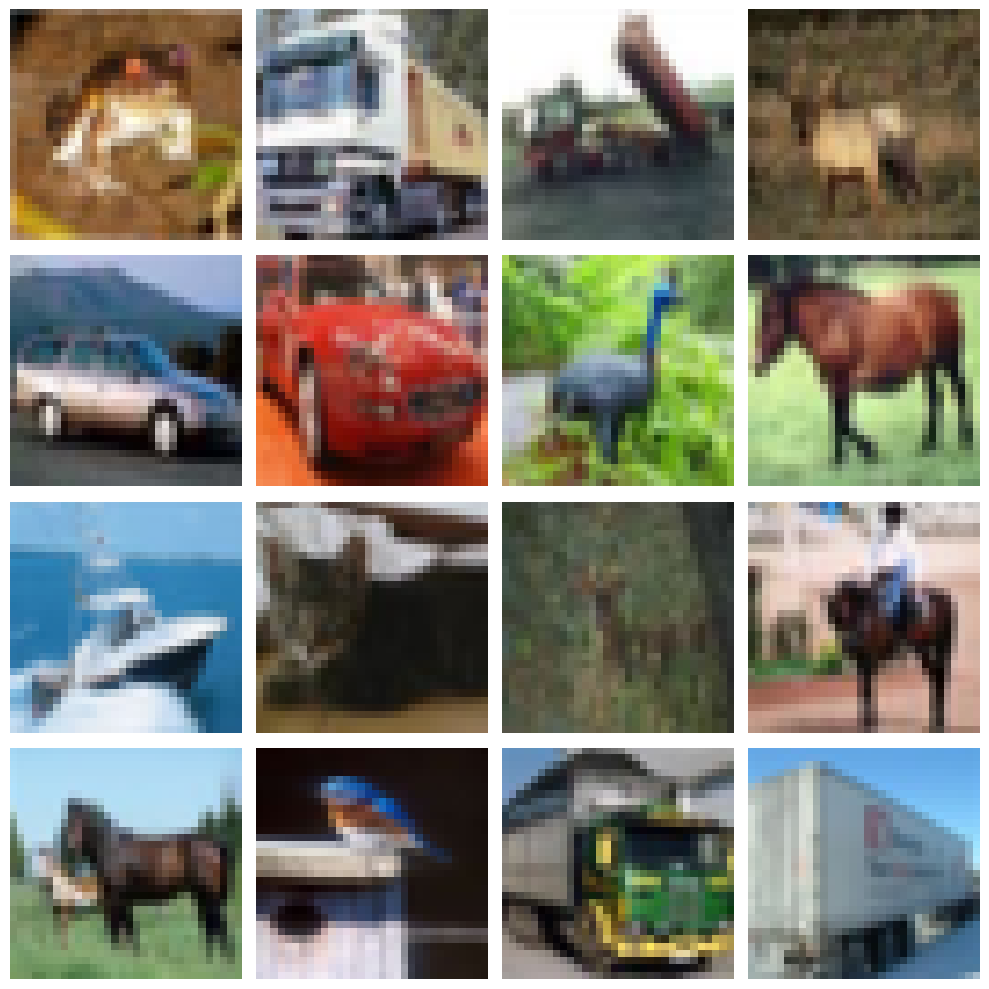

In [4]:
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4, i+1)
    plt.imshow(X_train[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
data_augmentation = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15), # +/-15° de rotation
    layers.RandomZoom(0.1), # +/-10% zoom
    layers.RandomContrast(0.2), # variation de contraste
])

(1, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015449941..1.0293715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0658692].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0627275].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0755].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0770371].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.035074472..1.0051038].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.018070221..1.0254197].
Clipping inpu

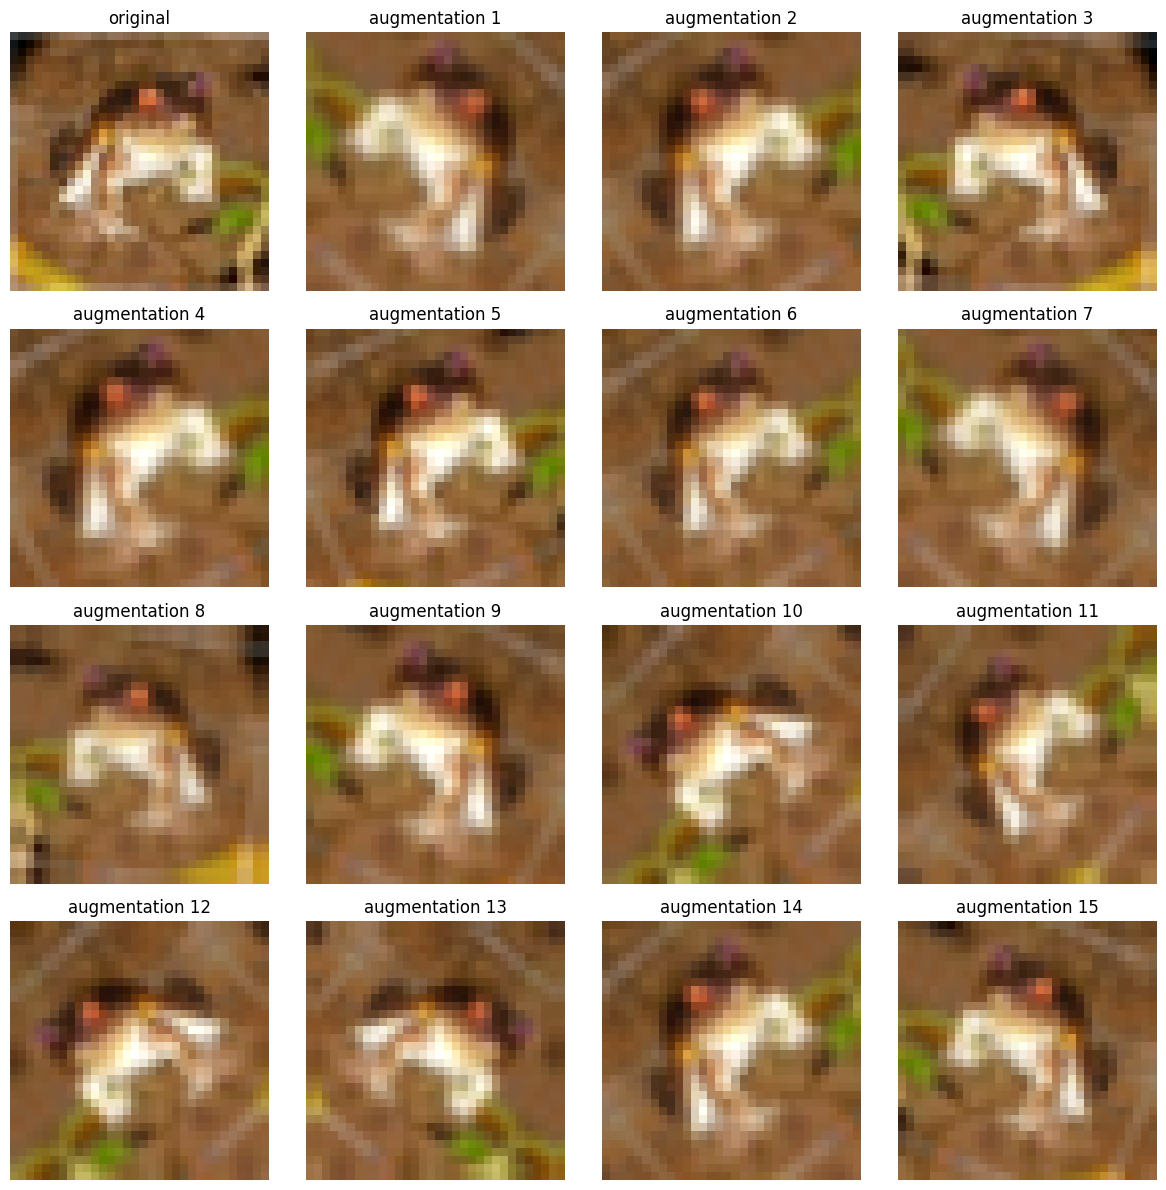

In [6]:
sample_img = X_train[0].astype("float32") / 255.0
sample_img_batch = tf.expand_dims(sample_img, 0)
print(sample_img_batch.shape)

plt.figure(figsize=(12,12))

plt.subplot(4,4,1)
plt.imshow(sample_img)
plt.title("original")
plt.axis("off")

for i in range(15):
    augmented_img = data_augmentation(sample_img_batch, training=True)
    plt.subplot(4,4, i +2)
    plt.imshow(augmented_img[0])
    plt.title(f"augmentation {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
def create_cnn_model(augmentation=False):
    model_layers = []

    if augmentation:
        model_layers.append(data_augmentation)
    
    model_layers.extend([
        layers.Conv2D(32, 3, activation="relu", input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(10, activation="softmax")
    ])

    model = keras.Sequential(model_layers)

    return model


In [8]:
model_no_aug = create_cnn_model()

model_no_aug.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_no_aug = model_no_aug.fit(
    X_train_norm, y_train_onehot,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5298 - loss: 1.3368 - val_accuracy: 0.5758 - val_loss: 1.1901
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6668 - loss: 0.9598 - val_accuracy: 0.5297 - val_loss: 1.4142
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7212 - loss: 0.8061 - val_accuracy: 0.6216 - val_loss: 1.1415
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7625 - loss: 0.6842 - val_accuracy: 0.6501 - val_loss: 1.0381
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7920 - loss: 0.5969 - val_accuracy: 0.7156 - val_loss: 0.8372


In [9]:
model_with_aug = create_cnn_model(augmentation=True)

model_with_aug.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_with_aug = model_with_aug.fit(
    X_train_norm, y_train_onehot,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4300 - loss: 1.6013 - val_accuracy: 0.4979 - val_loss: 1.4291
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5232 - loss: 1.3363 - val_accuracy: 0.5289 - val_loss: 1.3489
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5695 - loss: 1.2207 - val_accuracy: 0.5094 - val_loss: 1.5106
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5994 - loss: 1.1384 - val_accuracy: 0.5110 - val_loss: 1.4760
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6186 - loss: 1.0874 - val_accuracy: 0.5463 - val_loss: 1.3685
